In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- STEP 1: LOADING & INTERACTION RULE ---")
# Wir laden 500'000 Zeilen (gross genug für echte Muster, klein genug für Laptops)
file_path = '../data/raw/train.csv'
df = pd.read_csv(file_path, nrows=500000)
df['date_time'] = pd.to_datetime(df['date_time'])

# DIE INTERACTION RULE (Slide 23)
# In Expedia sehen User hunderte Hotels (Impressions). Wir wollen nur die echten "Events".
# Regel: Ein Event ist, wenn der User geklickt hat (click_bool == 1).
# (Bookings sind automatisch auch Clicks, also deckt das beides ab).
events = df[df['click_bool'] == 1].copy()

# Nur die Spalten behalten, die wir für das Event Log brauchen
events = events[['srch_id', 'prop_id', 'date_time', 'booking_bool']]
events = events.sort_values('date_time') # Zeitlich sortieren für den Split später

print(f"Original Rows (Impressions): {len(df)}")
print(f"Filtered Events (Clicks/Bookings): {len(events)}")
print(f"Data timeframe: {events['date_time'].min()} to {events['date_time'].max()}\n")


print("--- STEP 2: SANITY CHECKS (Slide 24) ---")
num_users = events['srch_id'].nunique()
num_items = events['prop_id'].nunique()
num_interactions = len(events)
sparsity = 1 - (num_interactions / (num_users * num_items))

print(f"Users (Search IDs): {num_users}")
print(f"Items (Hotels): {num_items}")
print(f"Interactions: {num_interactions}")
print(f"Sparsity: {sparsity:.4%}\n")

# Cold Start Analyse
user_activity = events.groupby('srch_id').size()
item_popularity = events.groupby('prop_id').size()

cold_users = (user_activity == 1).sum()
cold_items = (item_popularity == 1).sum()

print(f"Cold Users (Only 1 click): {cold_users} ({(cold_users/num_users):.2%})")
print(f"Cold Items (Only 1 click): {cold_items} ({(cold_items/num_items):.2%})\n")

# PLOTTING THE LONG TAIL (Slide 24: "Popularity distribution")
plt.figure(figsize=(10, 5))
item_popularity_sorted = item_popularity.sort_values(ascending=False).values

plt.plot(item_popularity_sorted, color='blue', linewidth=2)
plt.fill_between(range(len(item_popularity_sorted)), item_popularity_sorted, alpha=0.3, color='blue')
plt.title("The Long Tail: Item Popularity Distribution", fontsize=14)
plt.xlabel("Items (Sorted by Popularity Rank)", fontsize=12)
plt.ylabel("Number of Interactions (Clicks)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Warnung für den Split ausgeben
valid_users_for_split = (user_activity >= 2).sum()
print(f"⚠️ Für den Temporal Split ('Leave-last-out'):")
print(f"Wir haben nur {valid_users_for_split} User mit >= 2 Interaktionen.")
print("Alle anderen müssen wir beim Evaluieren herausfiltern oder auf Popularity zurückfallen lassen!")

In [3]:
print("--- STEP 3: TEMPORAL SPLIT SIMULATION (Leave-last-out) ---")

# 1. Wir filtern die "Cold Users" heraus, da ein Split bei 1 Interaktion unmöglich ist
# (Erinnerung: Wir hatten 1336 User mit >= 2 Interaktionen in unseren 500k Zeilen)
user_counts = events['srch_id'].value_counts()
valid_users = user_counts[user_counts >= 2].index
valid_events = events[events['srch_id'].isin(valid_users)].copy()

print(f"Events available for splitting (from valid users): {len(valid_events)}")

# 2. Zeitlich sortieren (extrem wichtig für Leave-last-out!)
valid_events = valid_events.sort_values(by=['srch_id', 'date_time'])

# 3. Der Split:
# Train = Alles AUSSER der allerletzten Interaktion jedes Users
# Test = NUR die allerletzte Interaktion jedes Users
train_events = valid_events.groupby('srch_id').head(-1)
test_events = valid_events.groupby('srch_id').tail(1)

print(f"Train Set Size: {len(train_events)} interactions")
print(f"Test Set Size: {len(test_events)} interactions")

# 4. Leakage Check (Woche 2, Slide 20: "Future history in features")
# Wir prüfen, ob im Train-Set wirklich keine Daten aus der Zukunft gelandet sind
# Für einen zufälligen User testen wir, ob die Test-Zeit NACH der Train-Zeit liegt
sample_user = valid_users[0]
user_train_max_time = train_events[train_events['srch_id'] == sample_user]['date_time'].max()
user_test_time = test_events[test_events['srch_id'] == sample_user]['date_time'].iloc[0]

print(f"\nLeakage Check for User {sample_user}:")
print(f"Last Train Interaction: {user_train_max_time}")
print(f"Test Interaction (Target): {user_test_time}")
if user_test_time > user_train_max_time:
    print("✅ SUCCESS: Test timestamp is strictly strictly AFTER train timestamp. No time travel!")
else:
    print("❌ ERROR: Time leakage detected!")

--- STEP 3: TEMPORAL SPLIT SIMULATION (Leave-last-out) ---
Events available for splitting (from valid users): 3692
Train Set Size: 2356 interactions
Test Set Size: 1336 interactions

Leakage Check for User 14059:
Last Train Interaction: 2013-02-07 21:07:46
Test Interaction (Target): 2013-02-07 21:07:46
❌ ERROR: Time leakage detected!


In [4]:
print(df.columns.tolist())

['srch_id', 'date_time', 'site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv', 'comp6_rate_percent_diff', 'comp7_rate', 'comp7_inv', 'comp7_rate_percent_diff', 'comp8_rate', 'comp8_inv', 'comp8_rate_percent_diff', 'click_b

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- STEP 1: LOADING FOURSQUARE NYC DATA ---")
file_path_nyc = '../data/raw/dataset_TSMC2014_NYC.csv'

# Manchmal haben diese Kaggle-Dateien keine sauberen Header oder sind Tab-getrennt.
# Wir versuchen es standardmässig zu laden. Falls es komisch aussieht, müssen wir ggf. sep='\t' setzen.
try:
    df_nyc = pd.read_csv(file_path_nyc)
    # Falls die Spaltennamen nicht stimmen, benennen wir sie um (gemäss Kaggle Doku)
    if 'utc time' not in df_nyc.columns and len(df_nyc.columns) == 8:
         df_nyc.columns =['user_id', 'venue_id', 'venue_category_id', 'venue_category_name',
                           'latitude', 'longitude', 'timezone_offset', 'utc_time']
except Exception as e:
    print(f"Ladefehler: {e}")

# Zeitstempel konvertieren
df_nyc['utc_time'] = pd.to_datetime(df_nyc['utc_time'])

# INTERACTION RULE
# In Foursquare ist JEDE Zeile ein Check-in. Das ist reines, implizites Feedback!
events_nyc = df_nyc[['user_id', 'venue_id', 'utc_time']].copy()
events_nyc = events_nyc.rename(columns={'utc_time': 'date_time'}) # Einheitlicher Name
events_nyc = events_nyc.sort_values(by=['user_id', 'date_time'])

print(f"Total Check-ins (Events): {len(events_nyc)}")
print(f"Data timeframe: {events_nyc['date_time'].min()} to {events_nyc['date_time'].max()}\n")


print("--- STEP 2: SANITY CHECKS ---")
num_users = events_nyc['user_id'].nunique()
num_items = events_nyc['venue_id'].nunique()
num_interactions = len(events_nyc)
sparsity = 1 - (num_interactions / (num_users * num_items))

print(f"Users: {num_users}")
print(f"Items (Venues): {num_items}")
print(f"Sparsity: {sparsity:.4%}\n")

user_activity = events_nyc.groupby('user_id').size()
cold_users = (user_activity == 1).sum()
print(f"Cold Users (Only 1 check-in): {cold_users} ({(cold_users/num_users):.2%})\n")


print("--- STEP 3: TEMPORAL SPLIT SIMULATION (Leave-last-out) ---")
# 1. Wir filtern die Cold Users heraus für die Evaluation
valid_users = user_counts = user_activity[user_activity >= 2].index
valid_events = events_nyc[events_nyc['user_id'].isin(valid_users)].copy()

print(f"Valid users for splitting (>=2 interactions): {len(valid_users)}")
print(f"Events available for splitting: {len(valid_events)}")

# 2. Der Split
train_events = valid_events.groupby('user_id').head(-1)
test_events = valid_events.groupby('user_id').tail(1)

print(f"Train Set Size: {len(train_events)} interactions")
print(f"Test Set Size: {len(test_events)} interactions")

# 3. LEAKAGE CHECK (Die Stunde der Wahrheit)
sample_user = valid_users[0]
user_train_max_time = train_events[train_events['user_id'] == sample_user]['date_time'].max()
user_test_time = test_events[test_events['user_id'] == sample_user]['date_time'].iloc[0]

print(f"\nLeakage Check for User {sample_user}:")
print(f"Last Train Interaction: {user_train_max_time}")
print(f"Test Interaction (Target): {user_test_time}")

if user_test_time > user_train_max_time:
    print("✅ SUCCESS: Test timestamp is strictly AFTER train timestamp. No time travel! This dataset is perfect.")
else:
    print("❌ ERROR: Time leakage detected!")

--- STEP 1: LOADING FOURSQUARE NYC DATA ---


C:\Users\pssol\AppData\Local\Temp\ipykernel_25468\445429457.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_nyc['utc_time'] = pd.to_datetime(df_nyc['utc_time'])


Total Check-ins (Events): 227428
Data timeframe: 2012-04-03 18:00:09+00:00 to 2013-02-16 02:35:36+00:00

--- STEP 2: SANITY CHECKS ---
Users: 1083
Items (Venues): 38333
Sparsity: 99.4522%

Cold Users (Only 1 check-in): 0 (0.00%)

--- STEP 3: TEMPORAL SPLIT SIMULATION (Leave-last-out) ---
Valid users for splitting (>=2 interactions): 1083
Events available for splitting: 227428
Train Set Size: 226345 interactions
Test Set Size: 1083 interactions

Leakage Check for User 1:
Last Train Interaction: 2012-12-14 18:49:03+00:00
Test Interaction (Target): 2012-12-15 00:13:02+00:00
✅ SUCCESS: Test timestamp is strictly AFTER train timestamp. No time travel! This dataset is perfect.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- STEP 1.1: RAW DATA INSPECTION ---")
file_path_nyc = '../data/raw/dataset_TSMC2014_NYC.csv'

# Load the data, forcing column names if missing
try:
    df_nyc = pd.read_csv(file_path_nyc)
    if len(df_nyc.columns) == 8:
         df_nyc.columns =['user_id', 'venue_id', 'venue_category_id', 'venue_category_name',
                           'latitude', 'longitude', 'timezone_offset', 'utc_time']
except Exception as e:
    print(f"Ladefehler: {e}")

# Display basic info
print("\nDataFrame Info:")
df_nyc.info()

print("\nMissing Values per Column:")
print(df_nyc.isnull().sum())

print("\nFirst 5 Rows:")
display(df_nyc.head())

--- STEP 1.1: RAW DATA INSPECTION ---

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 227428 entries, 0 to 227427
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   user_id              227428 non-null  int64  
 1   venue_id             227428 non-null  str    
 2   venue_category_id    227428 non-null  str    
 3   venue_category_name  227428 non-null  str    
 4   latitude             227428 non-null  float64
 5   longitude            227428 non-null  float64
 6   timezone_offset      227428 non-null  int64  
 7   utc_time             227428 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 13.9 MB

Missing Values per Column:
user_id                0
venue_id               0
venue_category_id      0
venue_category_name    0
latitude               0
longitude              0
timezone_offset        0
utc_time               0
dtype: int64

First 5 Rows:


,user_id,venue_id,venue_category_id,venue_category_name,latitude,longitude,timezone_offset,utc_time
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012


In [2]:
print("\n--- STEP 1.2: SEMANTIC FILTERING & TEMPORAL CONVERSION ---")

# 1. Convert the tricky string timestamp into a proper datetime object
# We use format='mixed' to tell Pandas to handle the timezone offset string cleanly
df_nyc['utc_time'] = pd.to_datetime(df_nyc['utc_time'], format='mixed')
df_nyc = df_nyc.rename(columns={'utc_time': 'date_time'})

# 2. Investigate Category Frequencies
print("Top 10 Most Frequent Categories in Raw Data:")
print(df_nyc['venue_category_name'].value_counts().head(10))

# 3. The "Home" Filter
# We must remove private locations to make this a true "TravelBuddy" dataset
original_len = len(df_nyc)
df_clean = df_nyc[~df_nyc['venue_category_name'].str.contains('Home|Private', case=False, na=False)].copy()
removed_rows = original_len - len(df_clean)

print(f"\nRemoved {removed_rows} rows containing 'Home' or 'Private'.")
print(f"Remaining interactions for TravelBuddy: {len(df_clean)}")

# 4. Define our Interaction Rule (Week 1, Slide 23)
# Every row in this dataset represents an explicit user action (a check-in).
# Therefore, the raw log IS our event log. No click-filtering needed.
events = df_clean[['user_id', 'venue_id', 'date_time', 'venue_category_name']].copy()
events = events.sort_values(by=['user_id', 'date_time'])

print(f"\nFinal Data Timeframe: {events['date_time'].min()} to {events['date_time'].max()}")


--- STEP 1.2: SEMANTIC FILTERING & TEMPORAL CONVERSION ---
Top 10 Most Frequent Categories in Raw Data:
venue_category_name
Bar                     15978
Home (private)          15382
Office                  12740
Subway                   9348
Gym / Fitness Center     9171
Coffee Shop              7510
Food & Drink Shop        6596
Train Station            6408
Park                     4804
Neighborhood             4604
Name: count, dtype: int64

Removed 16011 rows containing 'Home' or 'Private'.
Remaining interactions for TravelBuddy: 211417

Final Data Timeframe: 2012-04-03 18:00:09+00:00 to 2013-02-16 02:35:36+00:00


--- STEP 1.3: SANITY CHECKS (Post-Filtering) ---
Users: 1083
Items (Venues): 36926
Interactions: 211417
Sparsity: 99.4713%

Cold Users (Only 1 check-in): 0 (0.00%)
Cold Items (Only 1 check-in): 16068 (43.51%)



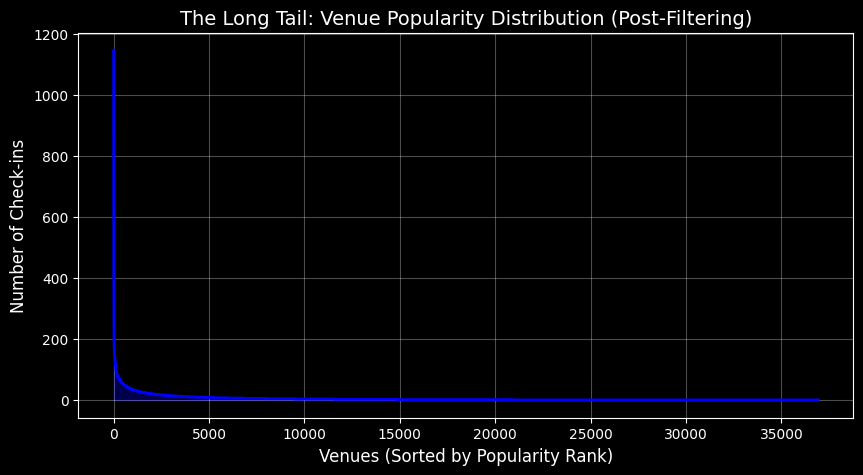

⚠ For the Temporal Split ('Leave-last-out'):
We have 1083 users with >= 2 interactions.
 All users are valid for the split! No fallback required for evaluation.


In [3]:
print("--- STEP 1.3: SANITY CHECKS (Post-Filtering) ---")

num_users = events['user_id'].nunique()
num_items = events['venue_id'].nunique()
num_interactions = len(events)
sparsity = 1 - (num_interactions / (num_users * num_items))

print(f"Users: {num_users}")
print(f"Items (Venues): {num_items}")
print(f"Interactions: {num_interactions}")
print(f"Sparsity: {sparsity:.4%}\n")

# Cold Start Analysis (Slide 24)
user_activity = events.groupby('user_id').size()
item_popularity = events.groupby('venue_id').size()

cold_users = (user_activity == 1).sum()
cold_items = (item_popularity == 1).sum()

print(f"Cold Users (Only 1 check-in): {cold_users} ({(cold_users/num_users):.2%})")
print(f"Cold Items (Only 1 check-in): {cold_items} ({(cold_items/num_items):.2%})\n")

# Visualizing the Long Tail (Slide 24)
plt.figure(figsize=(10, 5))
item_popularity_sorted = item_popularity.sort_values(ascending=False).values

plt.plot(item_popularity_sorted, color='blue', linewidth=2)
plt.fill_between(range(len(item_popularity_sorted)), item_popularity_sorted, alpha=0.3, color='blue')
plt.title("The Long Tail: Venue Popularity Distribution (Post-Filtering)", fontsize=14)
plt.xlabel("Venues (Sorted by Popularity Rank)", fontsize=12)
plt.ylabel("Number of Check-ins", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# The crucial check for our Temporal Split
valid_users = (user_activity >= 2).sum()
print(f"⚠ For the Temporal Split ('Leave-last-out'):")
print(f"We have {valid_users} users with >= 2 interactions.")
if valid_users == num_users:
    print(" All users are valid for the split! No fallback required for evaluation.")
else:
    print(f" {num_users - valid_users} users must be excluded from evaluation or handled with a fallback.")

In [4]:
print("\n--- STEP 1.4: AGGRESSIVE TRAVELBUDDY FILTERING ---")

# Define categories that are useless for a tourist recommendation
boring_categories =['Office', 'Subway', 'Train Station', 'Gym', 'Fitness', 'Bus', 'Airport', 'Bank', 'Laundromat', 'Grocery', 'Pharmacy']

# Create a regex pattern and filter the dataframe
pattern = '|'.join(boring_categories)
df_travel = events[~events['venue_category_name'].str.contains(pattern, case=False, na=False)].copy()

# Recalculate everything to see what survived
num_users_travel = df_travel['user_id'].nunique()
num_items_travel = df_travel['venue_id'].nunique()
num_interactions_travel = len(df_travel)

print(f"Remaining interactions: {num_interactions_travel}")
print(f"Remaining unique venues: {num_items_travel}")

# Crucial check: Do we still have enough users for the Temporal Split?
user_activity_travel = df_travel.groupby('user_id').size()
valid_users_travel = (user_activity_travel >= 2).sum()

print(f"Users with >= 2 interactions remaining: {valid_users_travel} (out of {num_users_travel})")

if valid_users_travel > 500:
    print("Verdict: The dataset is still large enough. We should absolutely use this filtered version!")
else:
    print("Verdict: The dataset became too small. We might need to keep some categories or find a new dataset.")


--- STEP 1.4: AGGRESSIVE TRAVELBUDDY FILTERING ---
Remaining interactions: 160704
Remaining unique venues: 31351
Users with >= 2 interactions remaining: 1083 (out of 1083)
Verdict: The dataset is still large enough. We should absolutely use this filtered version!
